# HR2: bootstrap confidence intervals (the sampling uncertainty)

Everything so far quantified **attribution** uncertainty (which pool, which list,
which treatment). This is the **other** uncertainty your framing promises and Milad
et al. (2024) formalise: **sampling** uncertainty. A month holds a finite number of
blocks; observe a slightly different sample and the metric shifts. The bootstrap
turns that into a confidence interval on every metric value.

Design: **both** resampling models, cross-checked - the nonparametric
**block-level** bootstrap (which, for count-based metrics, is *exactly* a
**multinomial** draw) and a **Poisson** draw (which also lets the block total vary);
**every scenario** in the H1-H5 x U1-U3 grid; **1000** iterations. This also closes
**RQ3 as originally specified** - the proposal's stability test was "CV threshold +
**bootstrap CI overlap of adjacent windows**," and this delivers the second half.

Reconstructs per-scenario counts from `raw_blocks_full.parquet` (known schema:
height, timestamp, coinbase_param, output_addresses)

In [2]:
%matplotlib inline
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

blk = pd.read_parquet("../data/raw/raw_blocks_full.parquet")
btc = json.load(open("../data/raw/pools.json", encoding="utf-8"))
btc_tag  = {t: v["name"] for t, v in btc["coinbase_tags"].items()}
btc_addr = {a: v["name"] for a, v in btc["payout_addresses"].items()}
print(f"{len(blk):,} blocks | {len(btc_tag)} tags, {len(btc_addr)} addresses")

954,375 blocks | 149 tags, 190 addresses


## Attribute every block, then derive the five heuristics

Tag match (regex, longest-first) and address match, then H1–H5 as combinations of the
two signals, plus the month bucket.

In [3]:
def decode_coinbase(h):
    if not h: return ""
    try: return bytes.fromhex(h).decode("utf-8", errors="ignore")
    except (ValueError, TypeError): return str(h)

_pat = re.compile("|".join(re.escape(t) for t in sorted(btc_tag, key=len, reverse=True)))
def tag_match(text):
    m = _pat.search(text); return btc_tag[m.group(0)] if m else None
def addr_match(addrs):
    if addrs is None: return None
    for a in addrs:
        if a in btc_addr: return btc_addr[a]
    return None

text = blk["coinbase_param"].astype("string").fillna("").map(decode_coinbase)
tp = pd.Series([tag_match(t) for t in text], dtype="object")                       # tag pool
ap = pd.Series([addr_match(a) for a in blk["output_addresses"]], dtype="object")   # address pool

# the five heuristics (each yields a per-block label, "unknown" where no match)
lab = pd.DataFrame({
    "H1": tp.where(tp.notna(), "unknown"),                                    # tag only
    "H2": ap.where(ap.notna(), "unknown"),                                    # address only
    "H3": tp.where(tp.notna(), ap).where(lambda s: s.notna(), "unknown"),     # union, tag-pref
    "H5": ap.where(ap.notna(), tp).where(lambda s: s.notna(), "unknown"),     # union, addr-pref
    "H4": tp.where(tp.notna() & ap.notna() & (tp == ap), "unknown"),          # intersection
})
month = pd.to_datetime(blk["timestamp"]).dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
print("tag coverage %.1f%% | address coverage %.1f%%" % (100*tp.notna().mean(), 100*ap.notna().mean()))

tag coverage 70.0% | address coverage 35.6%


## Metrics + bootstrap (vectorised, validated against the scalar definitions)

In [4]:
def metrics_matrix(C):
    """All six metrics over a (B, k) matrix of counts. Nakamoto uses strict >50%."""
    C = np.asarray(C, float); n = C.sum(axis=1, keepdims=True)
    p = np.divide(C, n, out=np.zeros_like(C), where=n > 0)
    ps = -np.sort(-p, axis=1)                                    # descending
    hhi = (p ** 2).sum(axis=1)
    cr3 = ps[:, :3].sum(axis=1); cr5 = ps[:, :5].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        logp = np.where(p > 0, np.log2(p), 0.0)
    shannon = -(p * logp).sum(axis=1)
    nak = (np.cumsum(ps, axis=1) <= 0.5).sum(axis=1) + 1
    pa = np.sort(p, axis=1); k = C.shape[1]; idx = np.arange(1, k + 1); den = pa.sum(axis=1)
    gini = np.where(den > 0, (2 * (idx * pa).sum(axis=1)) / (k * den) - (k + 1) / k, 0.0)
    return {"nakamoto": nak, "hhi": hhi, "gini": gini, "shannon": shannon, "cr3": cr3, "cr5": cr5}

METRICS = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]

def point_and_ci(counts, B=1000, seed=0):
    """Point estimate + 95% CI under multinomial(=block) and Poisson resampling."""
    c = np.asarray(counts, float); c = c[c > 0]
    if c.size == 0:
        return {m: (np.nan, (np.nan, np.nan), (np.nan, np.nan)) for m in METRICS}
    n = int(c.sum()); p = c / n
    pt = {m: float(v[0]) for m, v in metrics_matrix(c.reshape(1, -1)).items()}
    rng = np.random.default_rng(seed)
    Cm = rng.multinomial(n, p, size=B).astype(float)
    Cp = rng.poisson(c, size=(B, c.size)).astype(float)
    Mm, Mp = metrics_matrix(Cm), metrics_matrix(Cp)
    return {m: (pt[m],
                (np.percentile(Mm[m], 2.5), np.percentile(Mm[m], 97.5)),
                (np.percentile(Mp[m], 2.5), np.percentile(Mp[m], 97.5))) for m in METRICS}

def treat(counts, U):
    """Apply the unknown treatment to a window's pool-count Series (incl 'unknown')."""
    if U == "U1":
        return counts
    known = counts.drop("unknown", errors="ignore")
    if U == "U2":
        return known
    unk = counts.get("unknown", 0)                       # U3: fold unknown into largest known
    if unk > 0 and len(known):
        known = known.copy(); known.iloc[int(known.values.argmax())] += unk
    return known

## Run the bootstrap for every scenario and window

In [5]:
HEUR = ["H1", "H2", "H3", "H4", "H5"]; UNK = ["U1", "U2", "U3"]
per_h = {}                                     # per heuristic: month -> Series(pool -> count)
for H in HEUR:
    d = pd.DataFrame({"m": month.values, "p": lab[H].values})
    per_h[H] = {m: g["p"].value_counts() for m, g in d.groupby("m")}

rows = []
for H in HEUR:
    for U in UNK:
        for m, counts in per_h[H].items():
            res = point_and_ci(treat(counts, U).values, B=1000, seed=42)
            for met in METRICS:
                pt, (lm, hm), (lp, hp) = res[met]
                rows.append({"scenario": f"{H}/{U}", "heuristic": H, "treatment": U,
                             "month": m, "metric": met, "point": pt,
                             "ci_lo": lm, "ci_hi": hm, "ci_lo_pois": lp, "ci_hi_pois": hp})
ci = pd.DataFrame(rows)
os.makedirs("../data/derived", exist_ok=True)
ci.to_parquet("../data/derived/metrics_with_ci.parquet")
print(f"bootstrap done: {len(ci):,} (scenario x window x metric) rows with CIs, cached.")

bootstrap done: 18,900 (scenario x window x metric) rows with CIs, cached.


## Baseline (H1/U2): metrics over time with 95% CI bands

Point line with the multinomial CI shaded; the Poisson CI as dashed lines. That the
two nearly coincide is the cross-check, the CIs are not an artefact of the
resampling model.

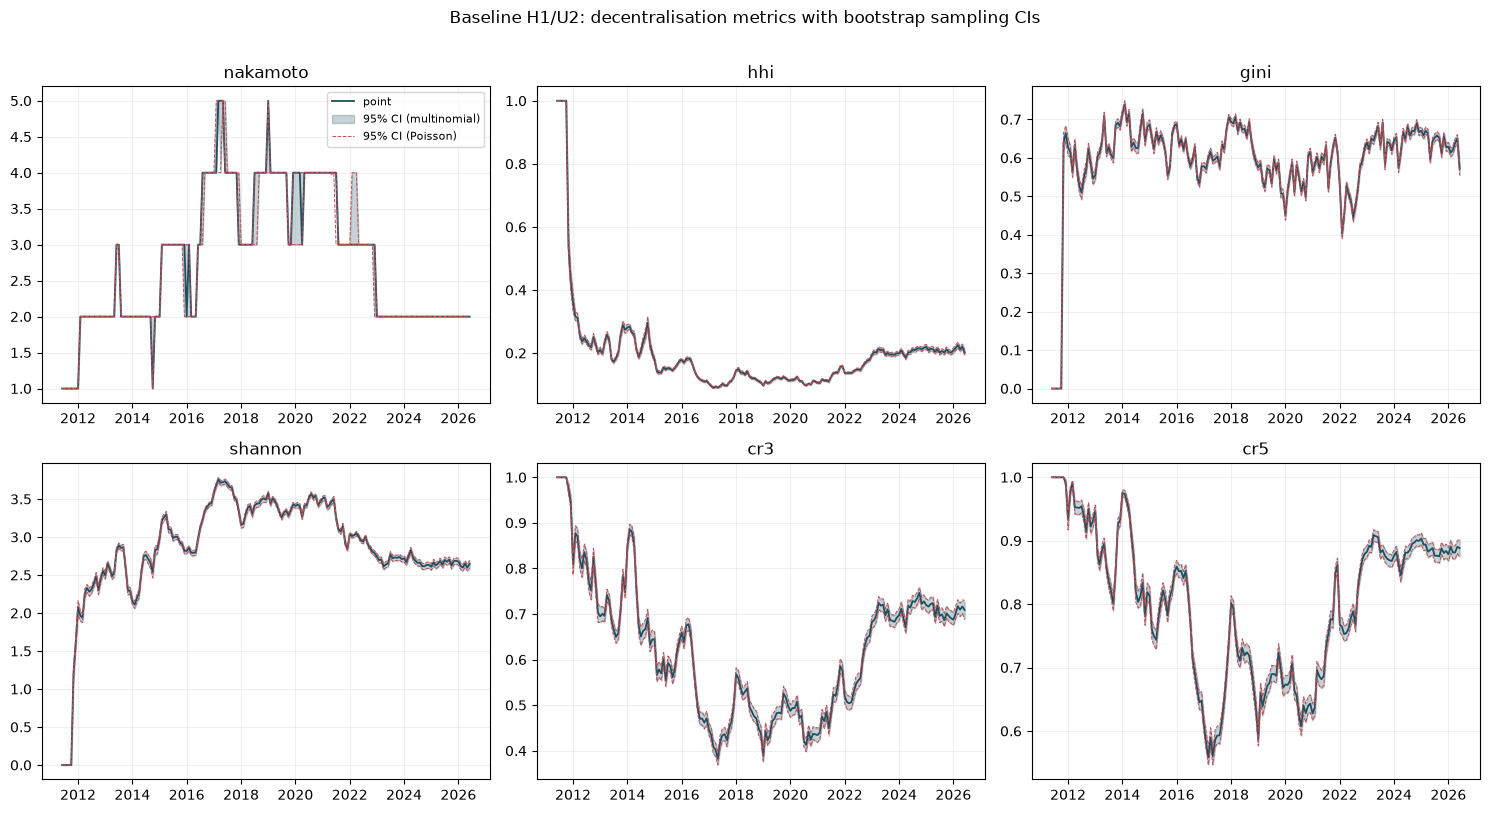

In [6]:
base = ci[ci["scenario"] == "H1/U2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, met in zip(axes.ravel(), METRICS):
    s = base[base["metric"] == met].sort_values("month")
    ax.plot(s["month"], s["point"], color="#1f4e5f", lw=1.3, label="point")
    ax.fill_between(s["month"], s["ci_lo"], s["ci_hi"], color="#1f4e5f", alpha=0.25,
                    label="95% CI (multinomial)")
    ax.plot(s["month"], s["ci_lo_pois"], ls="--", color="#c44e52", lw=0.7)
    ax.plot(s["month"], s["ci_hi_pois"], ls="--", color="#c44e52", lw=0.7, label="95% CI (Poisson)")
    ax.set_title(met); ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Baseline H1/U2: decentralisation metrics with bootstrap sampling CIs", y=1.01)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/bootstrap_ci_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

## Sampling uncertainty by scenario

Median CI half-width per metric per scenario over the reliable era (2018+). Wider =
noisier = fewer usable blocks. Watch the **low-coverage scenarios (H2, H4)**: they
should have the widest CIs, because attributing fewer blocks means each estimate rests
on a smaller sample, sampling and attribution uncertainty compound.

In [7]:
cut = pd.Timestamp("2018-01-01")
recent = ci[ci["month"] >= cut].copy()
recent["halfwidth"] = (recent["ci_hi"] - recent["ci_lo"]) / 2
tab = (recent.groupby(["scenario", "metric"])["halfwidth"].median()
       .unstack("metric").reindex(columns=METRICS)
       .reindex([f"{h}/{u}" for h in HEUR for u in UNK]))
print("median 95% CI half-width (2018+):")
print(tab.round(4).to_string())

median 95% CI half-width (2018+):
metric    nakamoto     hhi    gini  shannon     cr3     cr5
scenario                                                   
H1/U1          0.0  0.0042  0.0100   0.0350  0.0138  0.0120
H1/U2          0.0  0.0043  0.0103   0.0373  0.0141  0.0119
H1/U3          0.0  0.0058  0.0097   0.0380  0.0135  0.0111
H2/U1          0.0  0.0115  0.0088   0.0421  0.0116  0.0077
H2/U2          0.0  0.0072  0.0154   0.0445  0.0174  0.0114
H2/U3          0.0  0.0124  0.0083   0.0438  0.0095  0.0056
H3/U1          0.0  0.0042  0.0098   0.0381  0.0138  0.0125
H3/U2          0.0  0.0042  0.0097   0.0380  0.0140  0.0123
H3/U3          0.0  0.0048  0.0096   0.0383  0.0138  0.0122
H4/U1          0.0  0.0077  0.0097   0.0345  0.0105  0.0055
H4/U2          0.0  0.0061  0.0146   0.0370  0.0160  0.0076
H4/U3          0.0  0.0126  0.0086   0.0419  0.0081  0.0036
H5/U1          0.0  0.0042  0.0099   0.0385  0.0138  0.0126
H5/U2          0.0  0.0042  0.0096   0.0381  0.0140  0.0123
H5/U3 

## Cross-check + RQ3 closure

(1) Multinomial vs Poisson CI widths agree (validation). (2) The proposal's stated
RQ3 criterion: at each granularity a metric is stable if bootstrap CIs on **adjacent
windows overlap** for more than a pre-registered proportion of window pairs.

In [8]:
# (1) cross-check
b = ci[ci["scenario"] == "H1/U2"].copy()
hw_m = (b["ci_hi"] - b["ci_lo"]); hw_p = (b["ci_hi_pois"] - b["ci_lo_pois"])
rel = np.abs(hw_m - hw_p) / hw_m.replace(0, np.nan)
print(f"multinomial vs Poisson CI half-width: mean relative diff = {rel.mean():.1%} (should be small)")

# (2) adjacent-window CI overlap (proposal's stability criterion; e.g. pre-registered >0.50)
print("\nadjacent-window 95% CI overlap (monthly baseline):")
for met in METRICS:
    s = b[b["metric"] == met].sort_values("month").reset_index(drop=True)
    lo, hi = s["ci_lo"].values, s["ci_hi"].values
    overlap = (np.minimum(hi[:-1], hi[1:]) >= np.maximum(lo[:-1], lo[1:]))
    print(f"   {met:9}: {overlap.mean():.1%} of adjacent months overlap")

multinomial vs Poisson CI half-width: mean relative diff = 3.2% (should be small)

adjacent-window 95% CI overlap (monthly baseline):
   nakamoto : 82.8% of adjacent months overlap
   hhi      : 56.9% of adjacent months overlap
   gini     : 33.5% of adjacent months overlap
   shannon  : 56.0% of adjacent months overlap
   cr3      : 61.2% of adjacent months overlap
   cr5      : 60.3% of adjacent months overlap
